In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

import torch
from torch.optim.lr_scheduler import SequentialLR, CosineAnnealingLR, LinearLR
from torch.utils.data import DataLoader

sys.path.append("../")

from oxels.datasets import PerspectiveImagesDataset
from oxels.networks import SwinUNet
from oxels.losses import original_loss_func
from oxels.augmentation import HueShift, MotionBlur, RandomKernel, RandomBrightnessContrast, PixelNoise, Sobel, Scharr, SequenceStrategy
from oxels.visualization.plot_channels import plot_channels

In [5]:
# import wandb

# # Start a new wandb run to track this script.
# run = wandb.init(
#     entity="kl_divergence-rensselaer-polytechnic-institute",
#     project="oxels",
# )

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
#"harmless" augmentations
basic_augmentations = SequenceStrategy(
    [MotionBlur(), HueShift(), RandomBrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequenceStrategy(
    [RandomKernel(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequenceStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [8]:
files = glob.glob("../../schenectadata/image-matching-challenge-2022/train/*/images/*.jpg")
# files = glob.glob("../../Pictures/Screenshots/*.png")
dataset = PerspectiveImagesDataset(files, all_agumentations, 256+128, 256, 0.5)

In [9]:
batch_size = 4

In [10]:
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    num_workers=len(os.sched_getaffinity(0)),
    pin_memory=True,
    shuffle=True,
    drop_last=True
)

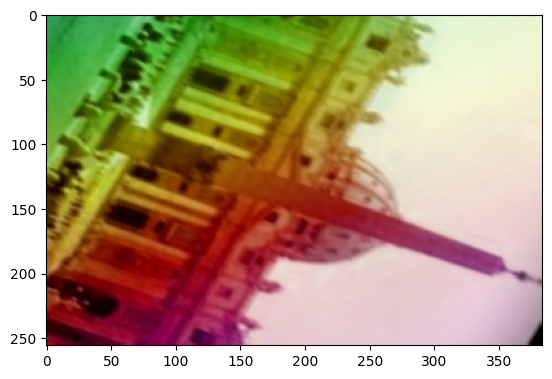

In [11]:
view1, view2, permutation, flags, mask1, mask2 = next(iter(loader))
plt.imshow(view1[0].detach().numpy().transpose((1,2,0)))

In [12]:
network = SwinUNet(
    channels=3, 
    patch_size=1,
    num_stages=4,
    patch_embed_dim=16,
    window_size=[3, 2],
    shift_size=0,
    oxel_dim=32,
    use_conv=True,
    add_identity=True
).to(device)

In [14]:
%%time
with torch.no_grad():
    oxels1 = network(view1.to(device))
    oxels2 = network(view2.to(device))
    print(original_loss_func(oxels1, oxels2, permutation.to(device), flags.to(device), mask1.to(device), mask2.to(device)))

tensor(0.1494, device='cuda:0')
CPU times: user 78.5 ms, sys: 0 ns, total: 78.5 ms
Wall time: 77.8 ms


In [ ]:
EPOCHS = 500
SAVE_EVERY = 100
LOG_EVERY = 100
LEARNING_RATE = 9e-5

optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)


warmup_epochs = 1
cosine_epochs = EPOCHS - warmup_epochs

scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=1e-6, end_factor=1.0, total_iters=warmup_epochs),
        CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=1e-6)
    ],
    milestones=[warmup_epochs]
)


for epoch in range(EPOCHS):
    network.train()
    total_loss = 0.0

    for step, (view1, view2, permutation, flags, mask1, mask2) in enumerate(loader):
        view1 = view1.to(device)
        view2 = view2.to(device)
        permutation = permutation.to(device)
        flags = flags.to(device)
        mask1 = mask1.to(device)
        mask2 = mask2.to(device)

        optimizer.zero_grad()
        oxels1 = network(view1)
        oxels2 = network(view2)

        loss = original_loss_func(oxels1, oxels2, permutation, flags, mask1, mask2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    avg_loss = total_loss / len(loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.3f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save model checkpoint
    if epoch % SAVE_EVERY == 0:
        torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

Epoch 1/500, Loss: 0.154, LR: 4.00e-06
Epoch 2/500, Loss: 0.140, LR: 8.00e-06
Epoch 3/500, Loss: 0.134, LR: 1.20e-05
Epoch 4/500, Loss: 0.132, LR: 1.60e-05
Epoch 5/500, Loss: 0.130, LR: 2.00e-05
Epoch 6/500, Loss: 0.130, LR: 2.40e-05
Epoch 7/500, Loss: 0.129, LR: 2.80e-05
Epoch 8/500, Loss: 0.129, LR: 3.20e-05
Epoch 9/500, Loss: 0.129, LR: 3.60e-05
Epoch 10/500, Loss: 0.128, LR: 4.00e-05
Epoch 11/500, Loss: 0.128, LR: 4.40e-05
Epoch 12/500, Loss: 0.128, LR: 4.80e-05
Epoch 13/500, Loss: 0.128, LR: 5.20e-05
Epoch 14/500, Loss: 0.128, LR: 5.60e-05
Epoch 15/500, Loss: 0.127, LR: 6.00e-05
Epoch 16/500, Loss: 0.127, LR: 6.40e-05
Epoch 17/500, Loss: 0.127, LR: 6.80e-05
Epoch 18/500, Loss: 0.127, LR: 7.20e-05
Epoch 19/500, Loss: 0.127, LR: 7.60e-05
Epoch 20/500, Loss: 0.126, LR: 8.00e-05
Epoch 21/500, Loss: 0.126, LR: 8.40e-05
Epoch 22/500, Loss: 0.126, LR: 8.80e-05
Epoch 23/500, Loss: 0.126, LR: 9.20e-05
Epoch 24/500, Loss: 0.126, LR: 9.60e-05
Epoch 25/500, Loss: 0.125, LR: 1.00e-04


/home/space/anaconda3/envs/oxels/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:198: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 26/500, Loss: 0.125, LR: 1.00e-04
Epoch 27/500, Loss: 0.125, LR: 1.00e-04
Epoch 28/500, Loss: 0.125, LR: 1.00e-04
Epoch 29/500, Loss: 0.125, LR: 1.00e-04
Epoch 30/500, Loss: 0.125, LR: 1.00e-04
Epoch 31/500, Loss: 0.125, LR: 1.00e-04
Epoch 32/500, Loss: 0.125, LR: 9.99e-05
Epoch 33/500, Loss: 0.125, LR: 9.99e-05
Epoch 34/500, Loss: 0.124, LR: 9.99e-05
Epoch 35/500, Loss: 0.124, LR: 9.99e-05
Epoch 36/500, Loss: 0.124, LR: 9.99e-05
Epoch 37/500, Loss: 0.124, LR: 9.98e-05
Epoch 38/500, Loss: 0.124, LR: 9.98e-05
Epoch 39/500, Loss: 0.124, LR: 9.98e-05
Epoch 40/500, Loss: 0.124, LR: 9.98e-05
Epoch 41/500, Loss: 0.124, LR: 9.97e-05
Epoch 42/500, Loss: 0.124, LR: 9.97e-05
Epoch 43/500, Loss: 0.124, LR: 9.96e-05
Epoch 44/500, Loss: 0.124, LR: 9.96e-05
Epoch 45/500, Loss: 0.124, LR: 9.96e-05
Epoch 46/500, Loss: 0.124, LR: 9.95e-05
Epoch 47/500, Loss: 0.124, LR: 9.95e-05
Epoch 48/500, Loss: 0.124, LR: 9.94e-05
Epoch 49/500, Loss: 0.124, LR: 9.94e-05
Epoch 50/500, Loss: 0.124, LR: 9.93e-05


KeyboardInterrupt: 

In [16]:
network.eval()

SwinUNet(
  (patch_embed): PatchEmbedding(
    (conv): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1), padding=same)
  )
  (encoder): SwinEncoder(
    (swin_blocks): ModuleList(
      (0): SwinBlock(
        (swtb1): SwinTransformerBlock(
          (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (attn): ShiftedWindowAttention(
            (qkv): Linear(in_features=16, out_features=48, bias=True)
            (proj): Linear(in_features=16, out_features=16, bias=True)
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
          (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (mlp): MLP(
            (0): Linear(in_features=16, out_features=64, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=64, out_features=16, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (swtb2): SwinTransformerBlock(
   

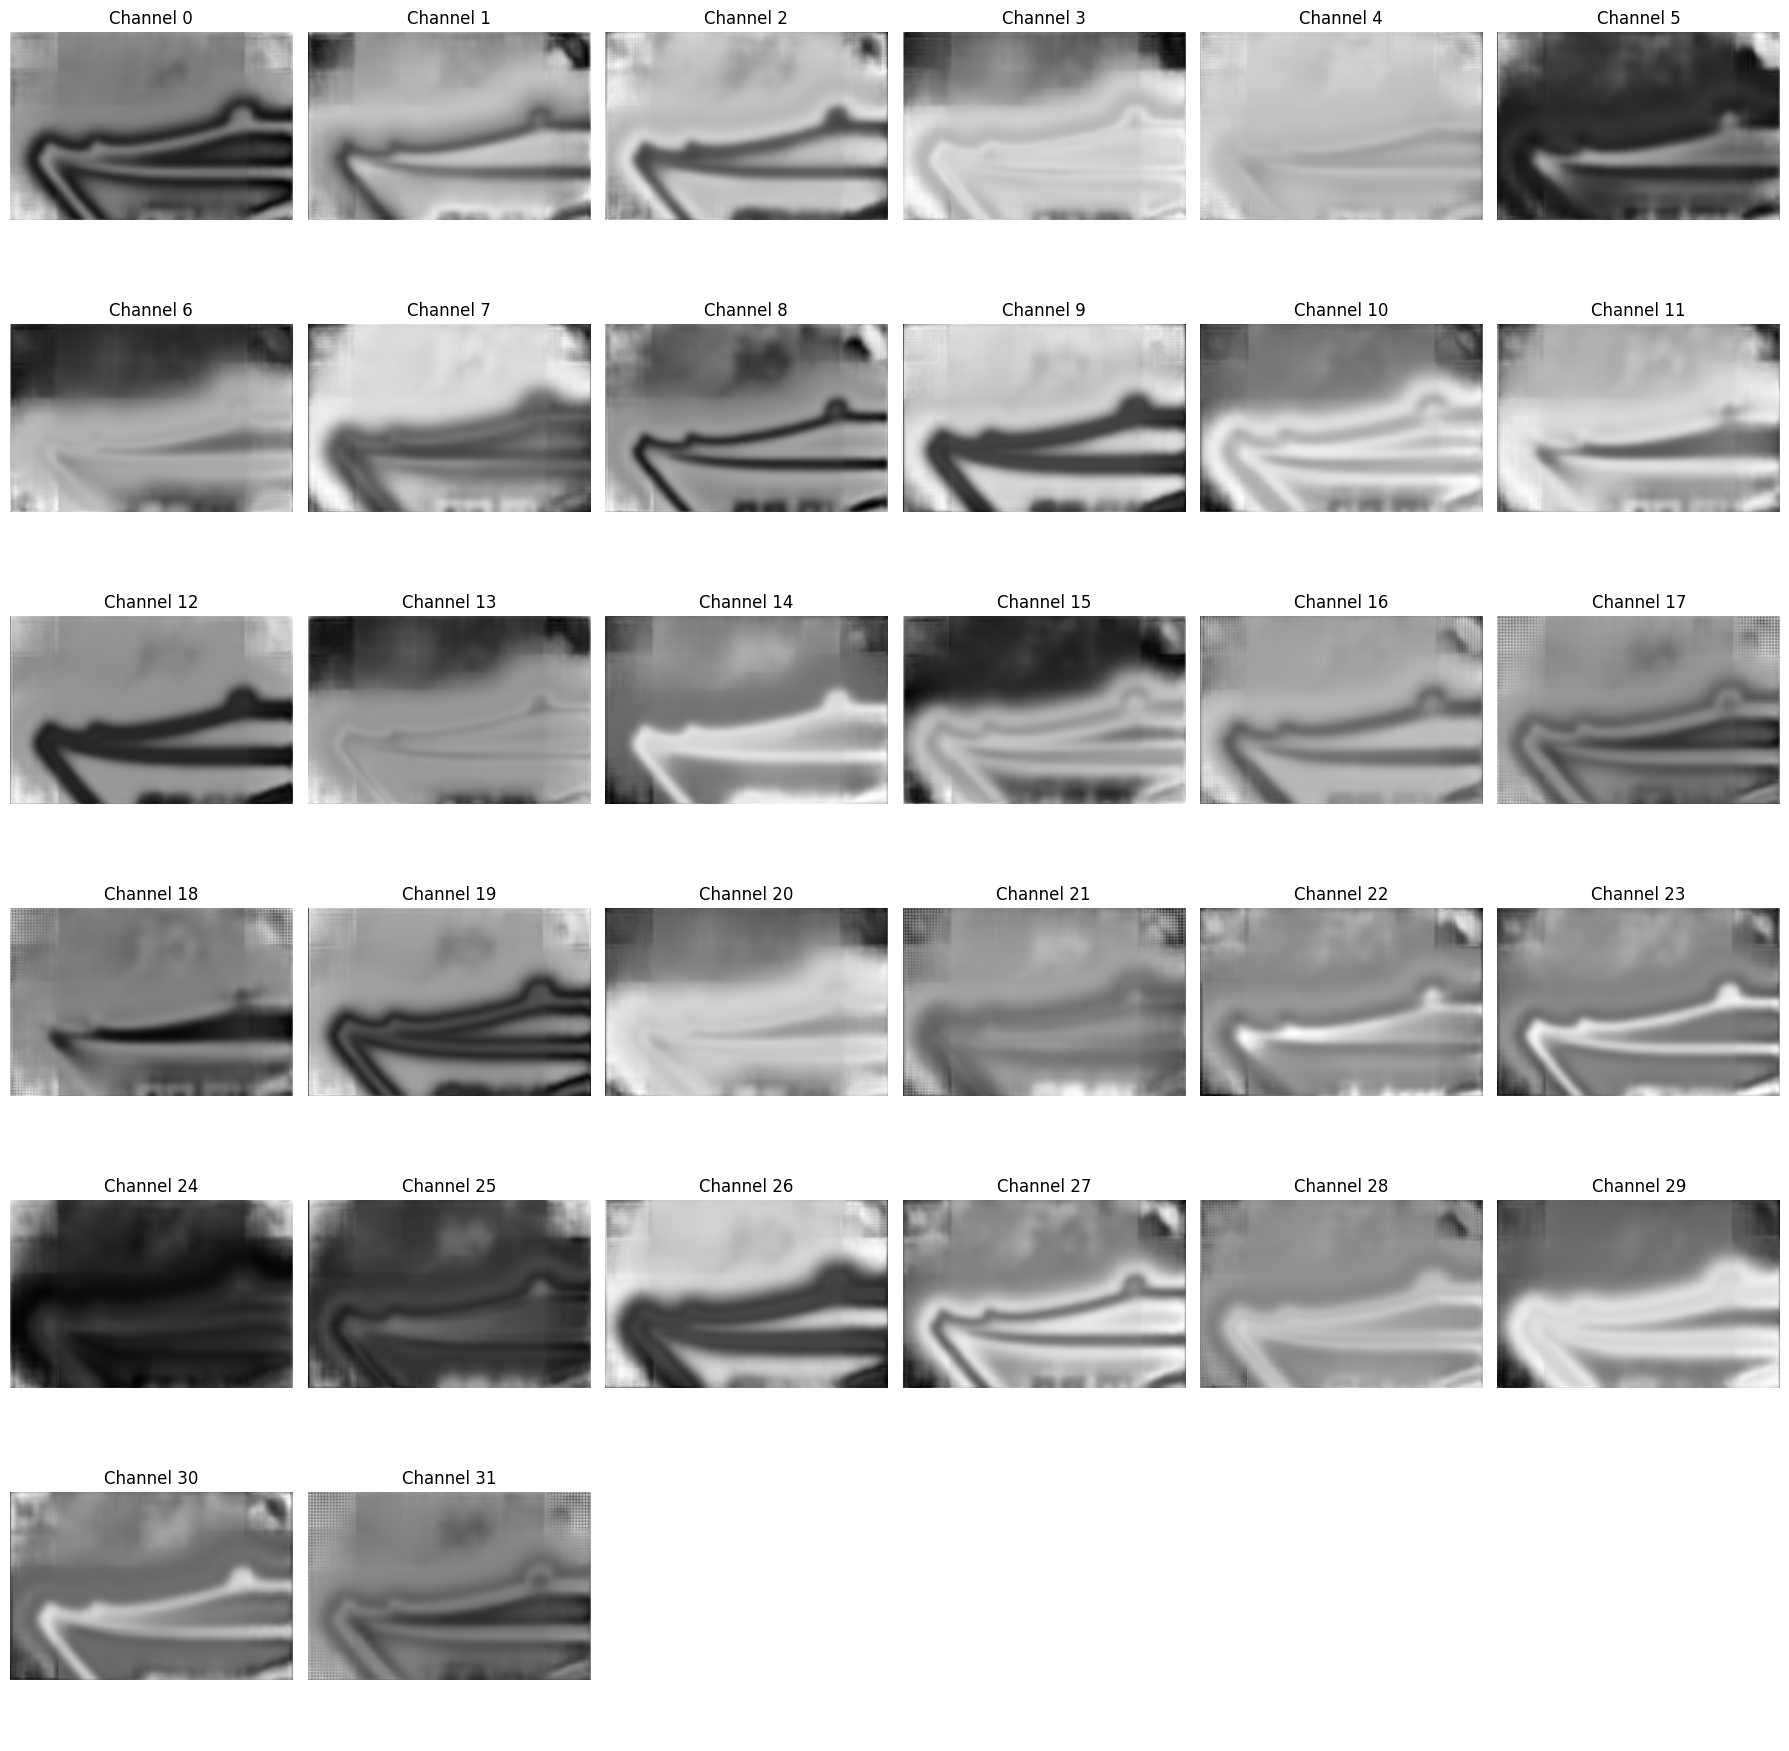

In [17]:
f = plot_channels(oxels2[1])

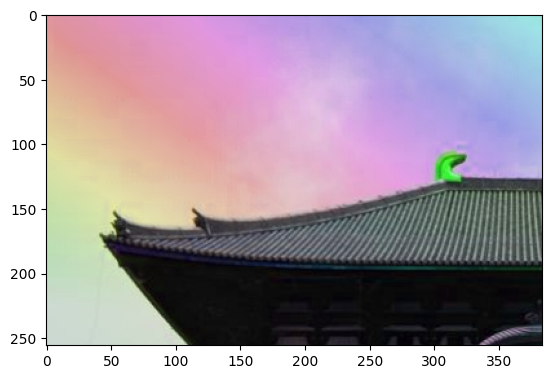

In [18]:
plt.imshow(np.transpose(view2[1].detach().cpu().numpy(), (1, 2, 0)))